# Polynomial Regression으로 Calories_Burned 예측하기

scikit-learn의 `PolynomialFeatures`와 `LinearRegression`을 조합하여 RMSE 최소화

주요 변화: 파생변수 weight 관련 추가 , 전처리부분 문자열 인코딩 꼬임 이슈 셀 정리, 

Polynomial Degree: 2 성능이 더 좋게 변화 (파생변수 추가 영향)

추가 실험 Feature Pruning RMSE 0.5370 !!

K-Fold 적용 후 타겟 정수화 RMSE 0.659748

## 1. 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
from tqdm.auto import tqdm

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. 랜덤 시드 고정

In [3]:
import random
import os

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42)

## 3. 데이터 로드

In [4]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain 데이터:")
display(train.head())

Train shape: (7500, 11)
Test shape: (7500, 10)

Train 데이터:


,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,F,45,166.0
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,M,50,33.0
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,M,29,23.0
3,TRAIN_0003,17.0,104.0,99.0,5.0,6.0,147.7,Normal Weight,F,33,91.0
4,TRAIN_0004,9.0,102.7,88.0,5.0,10.0,169.8,Normal Weight,M,38,32.0


## 4. 데이터 탐색

In [5]:
print('데이터 타입:')
print(train.dtypes)
print(f'\n결측치: {train.isnull().sum().sum()}')
print(f'\n타겟 변수 통계:')
print(train['Calories_Burned'].describe())

데이터 타입:
ID                           object
Exercise_Duration           float64
Body_Temperature(F)         float64
BPM                         float64
Height(Feet)                float64
Height(Remainder_Inches)    float64
Weight(lb)                  float64
Weight_Status                object
Gender                       object
Age                           int64
Calories_Burned             float64
dtype: object

결측치: 0

타겟 변수 통계:
count    7500.000000
mean       89.373467
std        62.817086
min         1.000000
25%        35.000000
50%        77.000000
75%       138.000000
max       300.000000
Name: Calories_Burned, dtype: float64


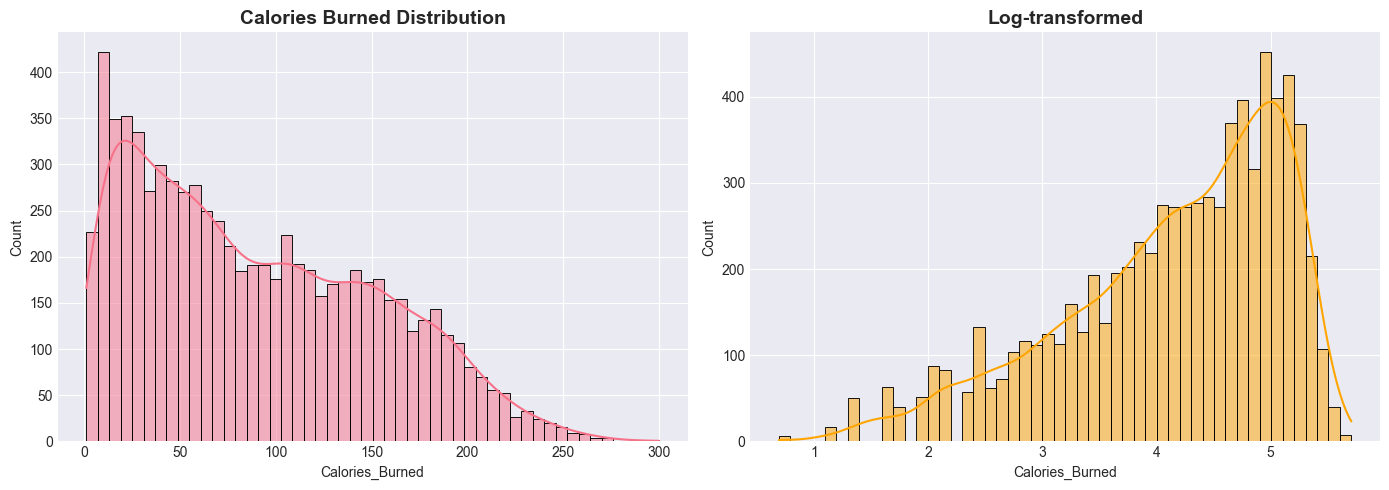

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['Calories_Burned'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Calories Burned Distribution', fontsize=14, fontweight='bold')

sns.histplot(np.log1p(train['Calories_Burned']), bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Log-transformed', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

오른쪽 꼬리 긴 분포 → 로그 변환 필요성 확인

## 5. 파생 변수 생성 (EDA 기반)


In [6]:
def create_features_safe(df):
    df = df.copy()

    # 1) 총 키 (인치)
    df['Height_Total_Inches'] = df['Height(Feet)'] * 12 + df['Height(Remainder_Inches)']

    # 2) 체온 차이 (98.6 기준)
    df['Temp_diff'] = df['Body_Temperature(F)'] - 98.6

    # 3) 운동 시간 구간화 (30 초과도 안전하게)
    df['Duration_bin'] = pd.cut(
        df['Exercise_Duration'],
        bins=[-np.inf, 10, 20, 30, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(int)

    # 4)~6) 상호작용
    df['Duration_x_BPM'] = df['Exercise_Duration'] * df['BPM']
    df['Duration_x_TempDiff'] = df['Exercise_Duration'] * df['Temp_diff']
    df['BPM_x_TempDiff'] = df['BPM'] * df['Temp_diff']

    # 7)~9) 제곱/3중
    df['Duration_sq'] = df['Exercise_Duration'] ** 2
    df['Temp_diff_sq'] = df['Temp_diff'] ** 2
    df['Dur_BPM_TempDiff'] = df['Exercise_Duration'] * df['BPM'] * df['Temp_diff']

    # 10)~11) 비율 (0 나누기 방지)
    df['BPM_per_Duration'] = df['BPM'] / (df['Exercise_Duration'] + 1)
    df['TempDiff_per_Duration'] = df['Temp_diff'] / (df['Exercise_Duration'] + 1)

    # 12) BMI (0 나누기 방지)
    h2 = (df['Height_Total_Inches'] ** 2).replace(0, np.nan)
    df['BMI'] = 703 * df['Weight(lb)'] / h2
    df['BMI'] = df['BMI'].fillna(df['BMI'].median())
    # 13) 체중×시간
    df['Weight_x_Duration'] = df['Weight(lb)'] * df['Exercise_Duration']

#추가
    
    # # 추가 핵심 파생
    # df['Weight_x_BPM'] = df['Weight(lb)'] * df['BPM']
    # df['Weight_x_BPM_x_Duration'] = df['Weight(lb)'] * df['BPM'] * df['Exercise_Duration']

    # df['Log_Weight'] = np.log1p(df['Weight(lb)'])
    # df['Log_BPM'] = np.log1p(df['BPM'])
    # df['Log_Duration'] = np.log1p(df['Exercise_Duration'])

    # df['Log_Weight_BPM_Dur'] = np.log1p(df['Weight(lb)'] * df['BPM'] * df['Exercise_Duration'])

    # df['BPM_per_Weight'] = df['BPM'] / (df['Weight(lb)'] + 1)
    # df['Dur_per_Weight'] = df['Exercise_Duration'] / (df['Weight(lb)'] + 1)

    return df

파생변수 생성 요약
1) 기본 변환

Height_Total_Inches: 키를 인치 단위로 통합
Temp_diff: 정상 체온(98.6°F) 기준 차이 → 운동 강도 반영
Duration_bin: 운동시간 구간화 (0-10, 10-20, 20-30)

2) 2차 상호작용

Duration_x_BPM: 운동 강도 (시간 × 심박수)
Duration_x_TempDiff: 운동 × 체온 상승
BPM_x_TempDiff: 심박수 × 체온 (심혈관 부하)
Weight_x_Duration: 체중 × 시간 (총 에너지 소비량)

3) 비선형 관계 포착

Duration_sq, Temp_diff_sq: 제곱항 (곡선 관계)
Dur_BPM_TempDiff: 3중 상호작용 (운동×심박×체온)

4) 비율 특성

BPM_per_Duration: 단위시간당 심박수 (운동 효율)
TempDiff_per_Duration: 단위시간당 체온 상승 (대사율)
BMI: 체질량지수 (기초 대사)

## 6. 전처리 세트

In [7]:
# 0) 원본에서 다시 시작
train_x = train.drop(['ID', 'Calories_Burned'], axis=1).copy()
train_y = train['Calories_Burned'].copy()
test_x  = test.drop(['ID'], axis=1).copy()

# 1) 파생변수
train_x = create_features_safe(train_x)
test_x  = create_features_safe(test_x)

# 2) 로그 타겟
train_y_log = np.log1p(train_y)

# 3) 원-핫 (컬럼이 있을 때만)
cat_cols = [c for c in ['Gender', 'Weight_Status'] if c in train_x.columns]
train_x = pd.get_dummies(train_x, columns=cat_cols, drop_first=True)
test_x  = pd.get_dummies(test_x,  columns=cat_cols, drop_first=True)

# 4) 컬럼 정렬
train_x, test_x = train_x.align(test_x, join='left', axis=1, fill_value=0)

print("인코딩 후 Train X shape:", train_x.shape)
print("인코딩 후 Test X shape:", test_x.shape)

인코딩 후 Train X shape: (7500, 23)
인코딩 후 Test X shape: (7500, 23)


In [ ]:
# # 항상 원본에서 다시 시작 (누적 방지)
# train_x = train.drop(['ID', 'Calories_Burned'], axis=1).copy()
# test_x  = test.drop(['ID'], axis=1).copy()

# before_cols = list(train_x.columns)

# train_x = create_features_safe(train_x)
# test_x  = create_features_safe(test_x)

# generated_cols = [c for c in train_x.columns if c not in before_cols]

# print("파생변수 생성 후 shape:", train_x.shape)
# print("\n생성된 파생변수 목록:")
# for i, col in enumerate(generated_cols, 1):
#     print(f"{i:2d}. {col}")

파생변수 생성 후 shape: (7500, 30)

생성된 파생변수 목록:
 1. Height_Total_Inches
 2. Temp_diff
 3. Duration_bin
 4. Duration_x_BPM
 5. Duration_x_TempDiff
 6. BPM_x_TempDiff
 7. Duration_sq
 8. Temp_diff_sq
 9. Dur_BPM_TempDiff
10. BPM_per_Duration
11. TempDiff_per_Duration
12. BMI
13. Weight_x_Duration
14. Weight_x_BPM
15. Weight_x_BPM_x_Duration
16. Log_Weight
17. Log_BPM
18. Log_Duration
19. Log_Weight_BPM_Dur
20. BPM_per_Weight
21. Dur_per_Weight


## 8. 타겟 변수 로그 변환

In [8]:
# 큰 값의 오차를 줄이고 분포를 정규화시키기
train_y_log = np.log1p(train_y)

print("로그 변환 전:", train_y.min(), "~", train_y.max())
print("로그 변환 후:", train_y_log.min(), "~", train_y_log.max())

로그 변환 전: 1.0 ~ 300.0
로그 변환 후: 0.6931471805599453 ~ 5.707110264748875


## 9. Train/Validation 분리

In [9]:
# 로그 변환된 타겟으로 분할 (원본 스케일 아님! 로그 학습시킬것임)
X_train, X_val, y_train, y_val = train_test_split(
    train_x, train_y_log,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (6000, 23)
X_val shape: (1500, 23)


In [10]:
print("X_train dtypes:")
print(X_train.dtypes)

print("\n문자열 컬럼:", X_train.select_dtypes(include=['object']).columns.tolist())
print("Weight_Status 값 예시:", X_train.select_dtypes(include=['object']).head(3))

X_train dtypes:
Exercise_Duration           float64
Body_Temperature(F)         float64
BPM                         float64
Height(Feet)                float64
Height(Remainder_Inches)    float64
Weight(lb)                  float64
Age                           int64
Height_Total_Inches         float64
Temp_diff                   float64
Duration_bin                  int64
Duration_x_BPM              float64
Duration_x_TempDiff         float64
BPM_x_TempDiff              float64
Duration_sq                 float64
Temp_diff_sq                float64
Dur_BPM_TempDiff            float64
BPM_per_Duration            float64
TempDiff_per_Duration       float64
BMI                         float64
Weight_x_Duration           float64
Gender_M                       bool
Weight_Status_Obese            bool
Weight_Status_Overweight       bool
dtype: object

문자열 컬럼: []
Weight_Status 값 예시: Empty DataFrame
Columns: []
Index: [4664, 4411, 7448]


## 10. Baseline: Linear Regression (degree=1)

In [10]:
lr_baseline = LinearRegression()
lr_baseline.fit(X_train, y_train) # 선형회귀모델 훈련데이터로 학습

y_pred_log = lr_baseline.predict(X_val) # 검증 데이터 예측 (로그 스케일 상태)
y_pred = np.expm1(y_pred_log) #로그 변환했던 걸 원래 스케일로 복원
y_true = np.expm1(y_val)      #로그를 썼기 때문에 expm1로 되돌리는 것

rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred)) # RMSE 계산
r2_baseline = r2_score(y_true, y_pred) # R² 데이터의 설명력 계산

print(f"Baseline Linear Regression")
print(f"  RMSE: {rmse_baseline:.4f}")
print(f"  R² Score: {r2_baseline:.4f}")

Baseline Linear Regression
  RMSE: 7.2631
  R² Score: 0.9862


degree=1 다항식 확장을 하지 않은 순수 선형 모델

23개 파생변수만으로도 R² 98.6% 달성 - 이미 선형 관계가 강하다는 증거 (굳이 복잡한 모델 필요 없었다)

## 11. Polynomial Regression (degree 비교)

In [11]:
degrees = [1, 2, 3]
results = []

for degree in degrees:
    print(f"\n{'='*60}")
    print(f"Polynomial Degree: {degree}")
    print(f"{'='*60}")

    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    print(f"원본 특성 수: {X_train.shape[1]}")
    print(f"다항 특성 수: {X_train_poly.shape[1]}")

    lr = LinearRegression()
    lr.fit(X_train_poly, y_train)

    y_pred_log = lr.predict(X_val_poly)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_val)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\nRMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    results.append({
        'degree': degree,
        'n_features': X_train_poly.shape[1],
        'rmse': rmse,
        'r2': r2,
        'model': lr,
        'poly': poly
    })

results_df = pd.DataFrame([{
    'Degree': r['degree'],
    'Features': r['n_features'],
    'RMSE': r['rmse'],
    'R²': r['r2']
} for r in results])

print(f"\n{'='*60}")
print("결과 요약")
print(f"{'='*60}")
display(results_df)


Polynomial Degree: 1
원본 특성 수: 23
다항 특성 수: 23

RMSE: 7.2631
R² Score: 0.9862

Polynomial Degree: 2
원본 특성 수: 23
다항 특성 수: 299

RMSE: 1.6915
R² Score: 0.9993

Polynomial Degree: 3
원본 특성 수: 23
다항 특성 수: 2599

RMSE: 0.9153
R² Score: 0.9998

결과 요약


,Degree,Features,RMSE,R²
0,1,23,7.263098,0.986245
1,2,299,1.691507,0.999254
2,3,2599,0.915293,0.999782


Degree 1: 23개 → RMSE 7.26

Degree 2: 299개 → RMSE 1.69 (76% 감소!)

Degree 3: 2599개 → RMSE 0.92 (46% 감소!)

Degree=3이 잘 나온 이유:

23개 특성 → 2599개 특성 생성

원본 특성 23개
2차 상호작용: C(23,2) = 253개
3차 상호작용: C(23,3) = 1771개
2차항, 3차항


약한 곡선 관계를 완벽히 포착

운동시간², 체온차이² 등의 비선형 효과
Duration × BPM × Temp 같은 복잡한 상호작용


R² 0.9998 = 99.98% 설명력



이번 파생변수 추가 시도로인해 생긴 결과 변화 : Degree2가 더 잘 나오게 됨 

Degree 1: 31개 → RMSE 7.08 (2.48% 감소!)

Degree 2: 527개 → RMSE 1.57 (7.10% 감소!)

Degree 3: 5983개 → RMSE 0.99 (7.6% 증가!)


파생변수 추가한것이 선형 + 2차 상호작용에는 도움이 됨 그런데 3차에서는 과적합 유발

지금 데이터는 이미 곱 구조가 많아서 degree=3까지 가면 중복된 고차항 폭증하는 경향이 있는것같다(노이즈 증폭)

pruning이후 파생변수 추가가 악영향을 끼친것같아 추가한 변수 주석처리함

## 12. 결과 시각화

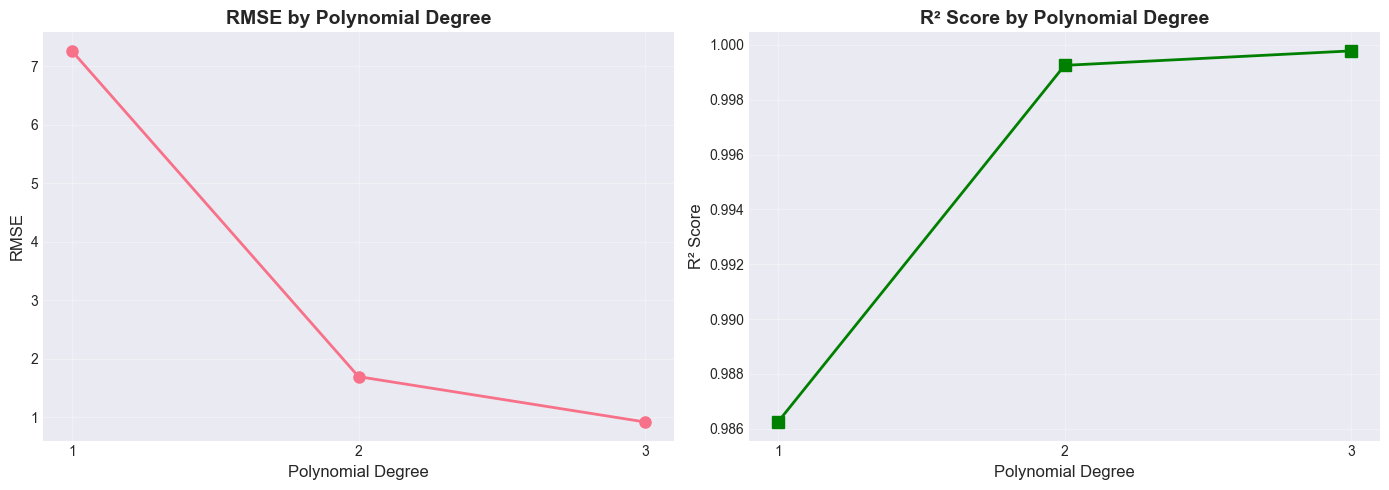


 최적 Polynomial Degree: 3
 최저 RMSE: 0.9153


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['Degree'], results_df['RMSE'], marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Polynomial Degree', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('RMSE by Polynomial Degree', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(results_df['Degree'])

axes[1].plot(results_df['Degree'], results_df['R²'], marker='s', color='green', linewidth=2, markersize=8)
axes[1].set_xlabel('Polynomial Degree', fontsize=12)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('R² Score by Polynomial Degree', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(results_df['Degree'])

plt.tight_layout()
plt.show()

best_idx = results_df['RMSE'].idxmin()
best_degree = results_df.loc[best_idx, 'Degree']
best_rmse = results_df.loc[best_idx, 'RMSE']

print(f"\n 최적 Polynomial Degree: {int(best_degree)}")
print(f" 최저 RMSE: {best_rmse:.4f}")

## 13. Regularization (Ridge & Lasso)

In [13]:
best_result = results[best_idx] # rmse가장 좋았던 degree 선택
poly = best_result['poly']

X_train_poly = poly.fit_transform(X_train) # 다항 학습
X_val_poly = poly.transform(X_val)

# Ridge 과적합방지
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_poly, y_train)
y_pred_ridge_log = ridge.predict(X_val_poly) # 로그 스케일 예측
y_pred_ridge = np.expm1(y_pred_ridge_log) # expm1로 원래 단위 복원
rmse_ridge = np.sqrt(mean_squared_error(np.expm1(y_val), y_pred_ridge)) # RMSE 계산

# Lasso 일부변수제거용
lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
lasso.fit(X_train_poly, y_train)
y_pred_lasso_log = lasso.predict(X_val_poly) # 로그 스케일 예측
y_pred_lasso = np.expm1(y_pred_lasso_log) # expm1로 원래 단위 복원
rmse_lasso = np.sqrt(mean_squared_error(np.expm1(y_val), y_pred_lasso)) # RMSE 계산

print(f"Degree {int(best_degree)} + Regularization:")
print(f"  Linear: {best_rmse:.4f}")
print(f"  Ridge: {rmse_ridge:.4f}")
print(f"  Lasso: {rmse_lasso:.4f}")

model_comparison = {
    'Linear': best_rmse,
    'Ridge': rmse_ridge,
    'Lasso': rmse_lasso
}

# RMSE 가장 낮은 모델 선택
best_model_name = min(model_comparison, key=model_comparison.get)
best_model_rmse = model_comparison[best_model_name]

print(f"\n 최종 최적 모델: {best_model_name} (degree={int(best_degree)})")
print(f" 최종 RMSE: {best_model_rmse:.4f}")

Degree 3 + Regularization:
  Linear: 0.9153
  Ridge: 1.2106
  Lasso: 0.9818

 최종 최적 모델: Linear (degree=3)
 최종 RMSE: 0.9153


Linear가 제일 좋다(2599개 특성인데도 과적합 심하지 않고 구조가 정말 다항식 형태에 가까워서 그런듯)
다항 확장된 고차항을 충분히 활용해야 성능이 나오며, 규제로 계수를 줄이면 오히려 표현력이 감소하는 구조인것같다

# 추가 실험 Feature Pruning

다항식 쓰면 피처 수 폭증 다중공선성 심해짐 계수 불안정해짐 ->과적합 위험

그래서 규제 모델을 실험해봅니다 Ridge/Lasso/ElasticNet을 validation RMSE 기준으로 비교



In [14]:
# ============================================================
# 기여도 기반 중요도 계산 + topN pruning 실험
# 중요도 = mean(|X_poly[:,j] * coef_j|)
# coef 절대값이 아니라 "실제 예측에 기여한 크기"로 정렬
# ============================================================

# 시도2 추가 과적합.. 모델이 외워버린듯 validation RMSE로 보게 하자 X_tr_poly로 학습 X_val_poly로 RMSE 계산

# 0) RMSE 함수 (원단위)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# 1) Train/Val split (log 타겟 기준)
X_tr, X_va, y_tr_log, y_va_log = train_test_split(
    train_x, train_y_log, test_size=0.2, random_state=42
)

y_va = np.expm1(y_va_log)  # RMSE는 원단위로 계산할 것

# 2) 후보 모델 세팅
#    - Polynomial + Scaler + Model
# alpha 후보 (필요하면 더 촘촘히)
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 1]
# ElasticNet 후보 (L1 비율)
l1_ratios = [0.2, 0.5, 0.8]

results = []

# 총 반복 횟수(진행률 정확하게)
total_steps = len(alphas) * 2 + len(alphas) * len(l1_ratios)
with tqdm(total=total_steps, desc="Tuning (Val RMSE)") as pbar:

    # 3) Ridge / Lasso 튜닝 (Val RMSE 기준)
    for a in alphas:
        # Ridge
        ridge_pipe = Pipeline([
            ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=a))
        ])
        ridge_pipe.fit(X_tr, y_tr_log)
        pred_log = ridge_pipe.predict(X_va)
        pred = np.clip(np.expm1(pred_log), 0, None)
        results.append(("Ridge", a, None, rmse(y_va, pred)))
        pbar.update(1)
        
        # Lasso
        lasso_pipe = Pipeline([
            ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("model", Lasso(alpha=a, max_iter=20000))
        ])
        lasso_pipe.fit(X_tr, y_tr_log)
        pred_log = lasso_pipe.predict(X_va)
        pred = np.clip(np.expm1(pred_log), 0, None)
        results.append(("Lasso", a, None, rmse(y_va, pred)))
        pbar.update(1)

    # 4) ElasticNet 튜닝 (Val RMSE 기준)
    for a in alphas:
        for r in l1_ratios:
            enet_pipe = Pipeline([
                ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(alpha=a, l1_ratio=r, max_iter=30000))
            ])
            enet_pipe.fit(X_tr, y_tr_log)
            pred_log = enet_pipe.predict(X_va)
            pred = np.clip(np.expm1(pred_log), 0, None)
            results.append(("ElasticNet", a, r, rmse(y_va, pred)))
            pbar.update(1)

res_df = pd.DataFrame(results, columns=["model", "alpha", "l1_ratio", "val_rmse"]).sort_values("val_rmse")
print("Val RMSE 상위 15개")
display(res_df.head(15))

best = res_df.iloc[0]
best_model = best["model"]
best_alpha = float(best["alpha"])
best_l1 = best["l1_ratio"]

print("\n BEST")
print(best)

# 5) BEST 설정으로 전체 train 재학습 → test 예측 
best_degree = int(best_degree)  # 최종 선택한 degree (3)

if best_model == "Ridge":
    final_pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=best_alpha))
    ])
elif best_model == "Lasso":
    final_pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=best_alpha, max_iter=30000))
    ])
else:
    final_pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=best_alpha, l1_ratio=float(best_l1), max_iter=50000))
    ])

final_pipe.fit(train_x, train_y_log)

test_pred_log = final_pipe.predict(test_x)
test_pred = np.clip(np.expm1(test_pred_log), 0, None)

print("\n Test 예측 통계")
print("min / max / mean:", float(test_pred.min()), float(test_pred.max()), float(test_pred.mean()))



Tuning (Val RMSE): 100%|██████████| 25/25 [16:20<00:00, 39.23s/it] 

Val RMSE 상위 15개


,model,alpha,l1_ratio,val_rmse
4,Ridge,0.0100,NaN,0.537095
6,Ridge,0.1000,NaN,0.592656
2,Ridge,0.0010,NaN,0.606998
0,Ridge,0.0001,NaN,0.637488
8,Ridge,1.0000,NaN,0.774439
10,ElasticNet,0.0001,0.2,1.121047
11,ElasticNet,0.0001,0.5,1.273826
12,ElasticNet,0.0001,0.8,1.406953
1,Lasso,0.0001,NaN,1.450521
13,ElasticNet,0.0010,0.2,1.645266



 BEST
model          Ridge
alpha           0.01
l1_ratio         NaN
val_rmse    0.537095
Name: 4, dtype: object

 Test 예측 통계
min / max / mean: 0.8105827791678483 315.06021945372436 89.71101710291796


Lasso는 너무 강하게 계수 0으로 만들어서 성능 손실, 	Ridge가 가장 안정적(계수를 줄이지만 0으로 만들지는 않음 다항항 구조 유지히면서 일반화 부드럽게 시도)

중요도 기반 pruning은 과적합 줄여보려고 한 시도였으나 고차항 중 중요 상호작용이 같이 제거되었나 오히려 RMSE가 커짐 그래서 최종 채택은 안함

결과: Ridge(alpha=0.01)가 가장 낮은 val RMSE(0.5370)를 기록하여 최종 모델로 선정했다.

규제 자체가 성능을 올린 것이 아니라, 다항 확장으로 비선형 관계를 모델링한 것이 핵심 개선 요인이었고, 

Ridge는 그 구조를 안정적으로 유지하면서 일반화를 도운듯


?????

0.6144.. 뭐가 변경된거지 왔다갔다하면서 바꾼게 많아서 모르겠다 눈물나네...
train_x가 덮어쓰기 된걸까 아ㅏㅏ 너무 괴로워...아ㅏㅏㅏㅏㅏㅏ
괜ㅊ팒아 다시 실행하면 될ㄷ거야 

In [15]:
print("train_x shape:", train_x.shape)
print("best_degree:", best_degree)

train_x shape: (7500, 23)
best_degree: 3


# K Fold Ridge Averaging


In [16]:

from sklearn.model_selection import KFold
from typing import Any
from tqdm.auto import tqdm  # 없으면: !pip install tqdm


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

degree = 3
alpha = 0.01

oof = np.zeros(len(train_x))
test_pred = np.zeros(len(test_x))

for fold, (tr_idx, va_idx) in enumerate(tqdm(kf.split(train_x),total=N_SPLITS, desc="KFold Ridge"), 1):
    X_tr, X_va = train_x.iloc[tr_idx], train_x.iloc[va_idx]
    y_tr_log, y_va_log = train_y_log.iloc[tr_idx], train_y_log.iloc[va_idx]

    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])

    pipe.fit(X_tr, y_tr_log)

    # validation
    pred_va = np.clip(np.expm1(pipe.predict(X_va)), 0, None)
    oof[va_idx] = pred_va

    fold_rmse = rmse(np.expm1(y_va_log), pred_va)
    tqdm.write(f"Fold {fold} RMSE: {fold_rmse:.6f}")

    # test
    pred_test = np.clip(np.expm1(pipe.predict(test_x)), 0, None)
    test_pred += pred_test / N_SPLITS

print("\nOOF RMSE:", rmse(np.expm1(train_y_log), oof))
print("Test mean:", test_pred.mean())

KFold Ridge:  20%|██        | 1/5 [00:00<00:02,  1.49it/s]

Fold 1 RMSE: 0.537095


KFold Ridge:  40%|████      | 2/5 [00:01<00:01,  1.70it/s]

Fold 2 RMSE: 0.628846


KFold Ridge:  60%|██████    | 3/5 [00:01<00:01,  1.69it/s]

Fold 3 RMSE: 0.640924


KFold Ridge:  80%|████████  | 4/5 [00:02<00:00,  1.77it/s]

Fold 4 RMSE: 0.582523


KFold Ridge: 100%|██████████| 5/5 [00:02<00:00,  1.76it/s]

Fold 5 RMSE: 0.581393

OOF RMSE: 0.5953239339380563
Test mean: 89.7089898332851


### KFold + logspace alpha 정밀 튜닝 (degree=3 고정)

In [17]:

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

N_SPLITS = 5
SEED = 42
degree = 3

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# 정밀 탐색: 1e-5 ~ 1e+1 (필요하면 범위 조절)
alphas = np.logspace(-5, 1, 25)   # 25개면 꽤 정밀 + 속도도 OK

rows = []
best_alpha = None
best_oof = 1e18

for alpha in tqdm(alphas, desc="alpha search"):
    oof = np.zeros(len(train_x))
    fold_scores = []

    for tr_idx, va_idx in kf.split(train_x):
        X_tr, X_va = train_x.iloc[tr_idx], train_x.iloc[va_idx]
        y_tr_log, y_va_log = train_y_log.iloc[tr_idx], train_y_log.iloc[va_idx]

        pipe = Pipeline([
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=float(alpha)))
        ])

        pipe.fit(X_tr, y_tr_log)

        pred_va = np.clip(np.expm1(pipe.predict(X_va)), 0, None)
        oof[va_idx] = pred_va

        fold_scores.append(rmse(np.expm1(y_va_log), pred_va))

    oof_rmse = rmse(np.expm1(train_y_log), oof)
    rows.append({
        "alpha": float(alpha),
        "oof_rmse": float(oof_rmse),
        "fold_rmse_mean": float(np.mean(fold_scores)),
        "fold_rmse_std": float(np.std(fold_scores)),
    })

    if oof_rmse < best_oof:
        best_oof = oof_rmse
        best_alpha = float(alpha)

df_alpha = pd.DataFrame(rows).sort_values("oof_rmse")
print("\n alpha 튜닝 결과 TOP 10")
display(df_alpha.head(10))

print(f"\n BEST alpha = {best_alpha} | OOF RMSE = {best_oof}")

alpha search: 100%|██████████| 25/25 [00:48<00:00,  1.95s/it]


 alpha 튜닝 결과 TOP 10


,alpha,oof_rmse,fold_rmse_mean,fold_rmse_std
12,0.010000,0.595324,0.594156,0.037269
11,0.005623,0.596353,0.595434,0.033096
10,0.003162,0.606957,0.605965,0.034684
13,0.017783,0.608432,0.606928,0.042754
9,0.001778,0.618467,0.617216,0.039319
8,0.001000,0.626864,0.625377,0.043151
14,0.031623,0.630338,0.628726,0.045048
7,0.000562,0.634669,0.632980,0.046270
6,0.000316,0.646274,0.644390,0.049307
15,0.056234,0.652261,0.650735,0.044586



 BEST alpha = 0.01 | OOF RMSE = 0.5953239339380563


### Best alpha 로 다시 KFold 평균 예측

In [18]:

best_alpha = float(best_alpha)   # 위 셀에서 나온 값 사용
degree = 3
kf = KFold(n_splits=5, shuffle=True, random_state=42)

test_pred = np.zeros(len(test_x))
oof = np.zeros(len(train_x))

for fold, (tr_idx, va_idx) in enumerate(tqdm(kf.split(train_x), total=5, desc="Final KFold"), 1):
    X_tr, X_va = train_x.iloc[tr_idx], train_x.iloc[va_idx]
    y_tr_log, y_va_log = train_y_log.iloc[tr_idx], train_y_log.iloc[va_idx]

    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=best_alpha))
    ])

    pipe.fit(X_tr, y_tr_log)

    pred_va = np.clip(np.expm1(pipe.predict(X_va)), 0, None)
    oof[va_idx] = pred_va

    pred_te = np.clip(np.expm1(pipe.predict(test_x)), 0, None)
    test_pred += pred_te / 5

    fold_rmse = rmse(np.expm1(y_va_log), pred_va)
    print(f"Fold {fold} RMSE: {fold_rmse:.6f}")

print("\n Final OOF RMSE:", rmse(np.expm1(train_y_log), oof))
print("Test mean:", float(test_pred.mean()))



Final KFold:  20%|██        | 1/5 [00:00<00:02,  1.61it/s]

Fold 1 RMSE: 0.537095


Final KFold:  40%|████      | 2/5 [00:01<00:01,  1.77it/s]

Fold 2 RMSE: 0.628846


Final KFold:  60%|██████    | 3/5 [00:01<00:01,  1.69it/s]

Fold 3 RMSE: 0.640924


Final KFold:  80%|████████  | 4/5 [00:02<00:00,  1.78it/s]

Fold 4 RMSE: 0.582523


Final KFold: 100%|██████████| 5/5 [00:02<00:00,  1.79it/s]

Fold 5 RMSE: 0.581393

 Final OOF RMSE: 0.5953239339380563
Test mean: 89.7089898332851


In [ ]:
submission = pd.read_csv('sample_submission.csv')
submission['Calories_Burned'] = test_pred  # KFold 결과

print("=" * 70)
print("KFold 결과로 제출파일 생성 중...")
print("=" * 70)

submission = pd.DataFrame({
    'ID': test['ID'],
    'Calories_Burned': test_pred  # test_pred 사용!
})

submission.to_csv('kfold_submission.csv', index=False)

print(f" 제출파일 저장 완료: kfold_submission.csv")
print(f"   Test 예측 평균: {test_pred.mean():.4f}")
print(f"   OOF RMSE: {rmse(np.expm1(train_y_log), oof):.6f}")
print("\n제출파일 미리보기:")
display(submission.head(10))

KFold 결과로 제출파일 생성 중...
 제출파일 저장 완료: kfold_submission.csv
   Test 예측 평균: 89.7040
   OOF RMSE: 0.659748

제출파일 미리보기:


,ID,Calories_Burned
0,TEST_0000,172.308664
1,TEST_0001,188.024945
2,TEST_0002,53.852310
3,TEST_0003,161.659877
4,TEST_0004,224.827943
5,TEST_0005,179.021740
6,TEST_0006,98.312209
7,TEST_0007,43.790196
8,TEST_0008,79.334599
9,TEST_0009,58.641080


In [19]:
submission = pd.read_csv('sample_submission.csv')
submission['Calories_Burned'] = test_pred  # KFold 결과

# 타겟 정수 반올림 (Calories_Burned는 정수값)
print("=" * 70)
print("정수 반올림 적용")
print("=" * 70)

# 반올림 전
print(f"반올림 전 평균: {test_pred.mean():.4f}")
print(f"반올림 전 범위: {test_pred.min():.2f} ~ {test_pred.max():.2f}")

# 정수 반올림
test_pred_rounded = np.round(test_pred)

print(f"\n반올림 후 평균: {test_pred_rounded.mean():.4f}")
print(f"반올림 후 범위: {test_pred_rounded.min():.0f} ~ {test_pred_rounded.max():.0f}")

# 두 가지 제출파일 생성

# 1) 반올림 안 한 버전
submission1 = pd.DataFrame({
    'ID': test['ID'],
    'Calories_Burned': test_pred
})
submission1.to_csv('kfold_submission.csv', index=False)
print("\n저장: kfold_submission.csv (반올림 X)")

# 2) 반올림 버전 (추천!)
submission2 = pd.DataFrame({
    'ID': test['ID'],
    'Calories_Burned': test_pred_rounded
})
submission2.to_csv('kfold_submission_rounded.csv', index=False)
print("저장: kfold_submission_rounded.csv (반올림 O)")

display(submission2.head(10))


정수 반올림 적용
반올림 전 평균: 89.7090
반올림 전 범위: 0.82 ~ 315.43

반올림 후 평균: 89.7073
반올림 후 범위: 1 ~ 315

저장: kfold_submission.csv (반올림 X)
저장: kfold_submission_rounded.csv (반올림 O)


,ID,Calories_Burned
0,TEST_0000,173.0
1,TEST_0001,189.0
2,TEST_0002,54.0
3,TEST_0003,162.0
4,TEST_0004,225.0
5,TEST_0005,179.0
6,TEST_0006,98.0
7,TEST_0007,44.0
8,TEST_0008,79.0
9,TEST_0009,59.0


In [ ]:
# def create_features_v2(df):
#     df = df.copy()

#     # 기존 파생
#     df['Height_Total_Inches'] = df['Height(Feet)'] * 12 + df['Height(Remainder_Inches)']
#     df['Temp_diff'] = df['Body_Temperature(F)'] - 98.6
#     df['Duration_bin'] = pd.cut(df['Exercise_Duration'],
#                                 bins=[-np.inf, 10, 20, 30, np.inf],
#                                 labels=[0, 1, 2, 3]).astype(int)

#     df['Duration_x_BPM'] = df['Exercise_Duration'] * df['BPM']
#     df['Duration_x_TempDiff'] = df['Exercise_Duration'] * df['Temp_diff']
#     df['BPM_x_TempDiff'] = df['BPM'] * df['Temp_diff']
#     df['Duration_sq'] = df['Exercise_Duration'] ** 2
#     df['Temp_diff_sq'] = df['Temp_diff'] ** 2
#     df['Dur_BPM_TempDiff'] = df['Exercise_Duration'] * df['BPM'] * df['Temp_diff']
#     df['BPM_per_Duration'] = df['BPM'] / (df['Exercise_Duration'] + 1)
#     df['TempDiff_per_Duration'] = df['Temp_diff'] / (df['Exercise_Duration'] + 1)

#     h2 = (df['Height_Total_Inches'] ** 2).replace(0, np.nan)
#     df['BMI'] = 703 * df['Weight(lb)'] / h2
#     df['BMI'] = df['BMI'].fillna(df['BMI'].median())

#     df['Weight_x_Duration'] = df['Weight(lb)'] * df['Exercise_Duration']

#     # 추가 핵심 파생 
#     df['Weight_x_BPM'] = df['Weight(lb)'] * df['BPM']
#     df['Weight_x_BPM_x_Duration'] = df['Weight(lb)'] * df['BPM'] * df['Exercise_Duration']

#     df['Log_Weight'] = np.log1p(df['Weight(lb)'])
#     df['Log_BPM'] = np.log1p(df['BPM'])
#     df['Log_Duration'] = np.log1p(df['Exercise_Duration'])

#     # 곱 구조를 로그로 선형화
#     df['Log_Weight_BPM_Dur'] = np.log1p(df['Weight(lb)'] * df['BPM'] * df['Exercise_Duration'])

#     # 체중당 강도/시간
#     df['BPM_per_Weight'] = df['BPM'] / (df['Weight(lb)'] + 1)
#     df['Dur_per_Weight'] = df['Exercise_Duration'] / (df['Weight(lb)'] + 1)

#     return df

In [ ]:
# train_x2 = create_features_v2(train_x)
# test_x2  = create_features_v2(test_x)

# print(train_x2.shape, test_x2.shape)

(7500, 31) (7500, 31)


## 15. Test 데이터 예측

Test 예측 완료!
예측값 범위: 0.86 ~ 312.11
예측값 평균: 89.70
예측값 표준편차: 62.07


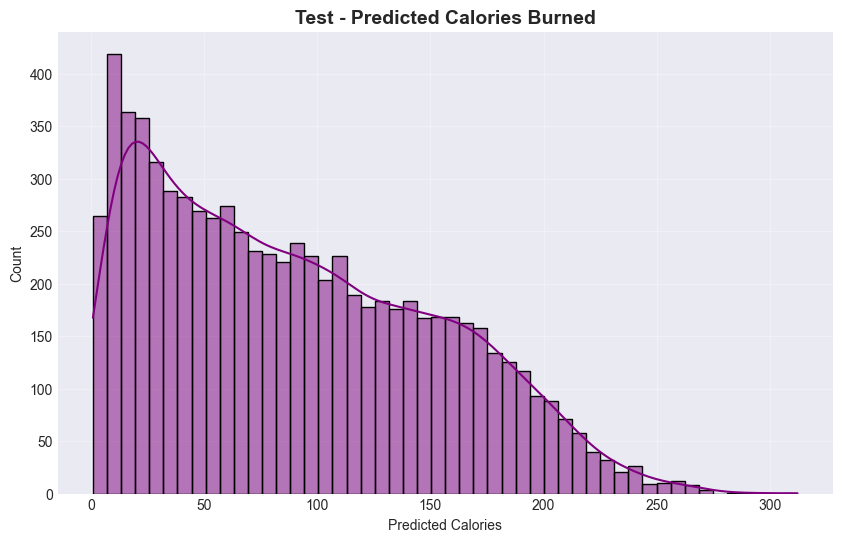

In [ ]:
# #test_pred_log = final_model.predict(test_x_poly_final) #  train_y_log로 학습했기에 이 예측값은 log1p(Calories) 상태
# #test_pred = np.expm1(test_pred_log) # log1p를 썼으니까 복원은 expm1 (이제 실제 단위가 됨)

# # 1) log 스케일 예측
# test_pred_log = final_pipe.predict(test_x) #  train_y_log로 학습했기에 이 예측값은 log1p(Calories) 상태

# # 2) 원단위 복원 + 음수 방지
# test_pred = np.clip(np.expm1(test_pred_log), 0, None) # log1p를 썼으니까 복원은 expm1 (이제 실제 단위가 됨)

# print("Test 예측 완료!")
# print(f"예측값 범위: {test_pred.min():.2f} ~ {test_pred.max():.2f}")
# print(f"예측값 평균: {test_pred.mean():.2f}")
# print(f"예측값 표준편차: {test_pred.std():.2f}")


# plt.figure(figsize=(10, 6))
# sns.histplot(test_pred, bins=50, kde=True, color='purple')
# plt.title('Test - Predicted Calories Burned', fontsize=14, fontweight='bold')
# plt.xlabel('Predicted Calories')
# plt.grid(True, alpha=0.3)
# plt.show()

## 16. 제출 파일 생성

In [ ]:
# submission = pd.read_csv('sample_submission.csv')
# submission['Calories_Burned'] = test_pred
# submission.to_csv('polynomial_regression_submit.csv', index=False)

# print("제출 파일 저장: polynomial_regression_submit.csv")
# display(submission.head(10))

제출 파일 저장: polynomial_regression_submit.csv


,ID,Calories_Burned
0,TEST_0000,172.260063
1,TEST_0001,188.079847
2,TEST_0002,53.811863
3,TEST_0003,161.727254
4,TEST_0004,224.960440
5,TEST_0005,179.214382
6,TEST_0006,98.314942
7,TEST_0007,43.788274
8,TEST_0008,79.369239
9,TEST_0009,58.648958


## 17. 성능 요약

In [ ]:
# print("="*70)
# print("최종 모델 성능 요약")
# print("="*70)
# print(f" 모델: {best_model_name} + PolynomialFeatures")
# print(f" Degree: {int(best_degree)}")
# print(f" 원본 특성: {train_x.shape[1]}개")
# print(f" 다항 특성: {train_x_poly_final.shape[1]}개")
# print(f" Validation RMSE: {best_model_rmse:.4f}")
# print("="*70)
# print("\n 사용된 EDA 파생변수:")
# print("  - Height_Total_Inches (총 키)")
# print("  - Temp_diff (체온 차이)")
# print("  - Duration_bin (운동시간 구간)")
# print("  - Duration_x_BPM (운동강도)")
# print("  - Duration_x_TempDiff (운동×체온)")
# print("  - BPM_x_TempDiff (심박×체온)")
# print("  - Duration_sq (운동시간 제곱)")
# print("  - Temp_diff_sq (체온차이 제곱)")
# print("  - Dur_BPM_TempDiff (3중 상호작용)")
# print("  - BPM_per_Duration (단위시간당 심박)")
# print("  - TempDiff_per_Duration (단위시간당 체온차이)")
# print("  - BMI (체질량지수)")
# print("  - Weight_x_Duration (체중×시간)")

## 제출 후 리더보드 점수 : 0.8941 드디ㅣ어 1점 아래로 내려왔다 ㅏㅏㅏ아ㅏㅏㅏㅏ!!!!!!